In [24]:
import numpy as np
from scipy.signal import detrend
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Load Raw Data ===
ambient_vib_pcb = np.load("ambient_vib_pcb.npy")
ambient_vib_wsn = np.load("ambient_vib_wsn.npy")
free_vib_pcb = np.load("free_vib_pcb.npy")
free_vib_wsn = np.load("free_vib_wsn.npy")

# === Coordinate Transformation Function (PCB → WSN-aligned) ===
def transform_pcb_to_wsn(pcb_data):
    transformed = np.empty_like(pcb_data)
    for sensor_index in range(4):
        base = sensor_index * 3
        pcb_x = pcb_data[:, base + 0]
        pcb_y = pcb_data[:, base + 1]
        pcb_z = pcb_data[:, base + 2]
        # Apply coordinate transformation rules
        transformed[:, base + 0] = -pcb_y  # WSN X
        transformed[:, base + 1] =  pcb_x  # WSN Y
        transformed[:, base + 2] =  pcb_z  # WSN Z
    return transformed

# === Apply transformation to PCB data, WSN is copied directly ===
am_pcb_aligned   = transform_pcb_to_wsn(ambient_vib_pcb)
am_wsn_aligned   = ambient_vib_wsn.copy()

free_pcb_aligned = transform_pcb_to_wsn(free_vib_pcb)
free_wsn_aligned = free_vib_wsn.copy()

# === Optional: Print Shape Info ===
print("am_pcb_aligned:   ", am_pcb_aligned.shape)
print("am_wsn_aligned:   ", am_wsn_aligned.shape)
print("free_pcb_aligned: ", free_pcb_aligned.shape)
print("free_wsn_aligned: ", free_wsn_aligned.shape)


am_pcb_aligned:    (614400, 12)
am_wsn_aligned:    (41999, 12)
free_pcb_aligned:  (614400, 12)
free_wsn_aligned:  (29999, 12)


In [25]:
# === Preprocessing Function ===
def preprocess_signal(signal_data):
    """
    Apply linear detrending and mean removal to each column (channel) of the input signal matrix.

    Parameters:
        signal_data (np.ndarray): Input signal, shape (N, 12)

    Returns:
        np.ndarray: Preprocessed signal of same shape
    """
    processed = np.empty_like(signal_data)
    for i in range(signal_data.shape[1]):
        # Linear detrend
        detrended = detrend(signal_data[:, i], type='linear')
        # Remove mean
        demeaned = detrended - np.mean(detrended)
        processed[:, i] = demeaned
    return processed

# === Apply to both ambient and free vibration data (PCB and WSN) ===
am_pcb_processed   = preprocess_signal(am_pcb_aligned)
am_wsn_processed   = preprocess_signal(am_wsn_aligned)
free_pcb_processed = preprocess_signal(free_pcb_aligned)
free_wsn_processed = preprocess_signal(free_wsn_aligned)

# === Confirm shapes match ===
print("am_pcb_processed:   ", am_pcb_processed.shape)
print("am_wsn_processed:   ", am_wsn_processed.shape)
print("free_pcb_processed: ", free_pcb_processed.shape)
print("free_wsn_processed: ", free_wsn_processed.shape)


am_pcb_processed:    (614400, 12)
am_wsn_processed:    (41999, 12)
free_pcb_processed:  (614400, 12)
free_wsn_processed:  (29999, 12)


In [26]:
# === Channel Labels (for y-axis)
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]


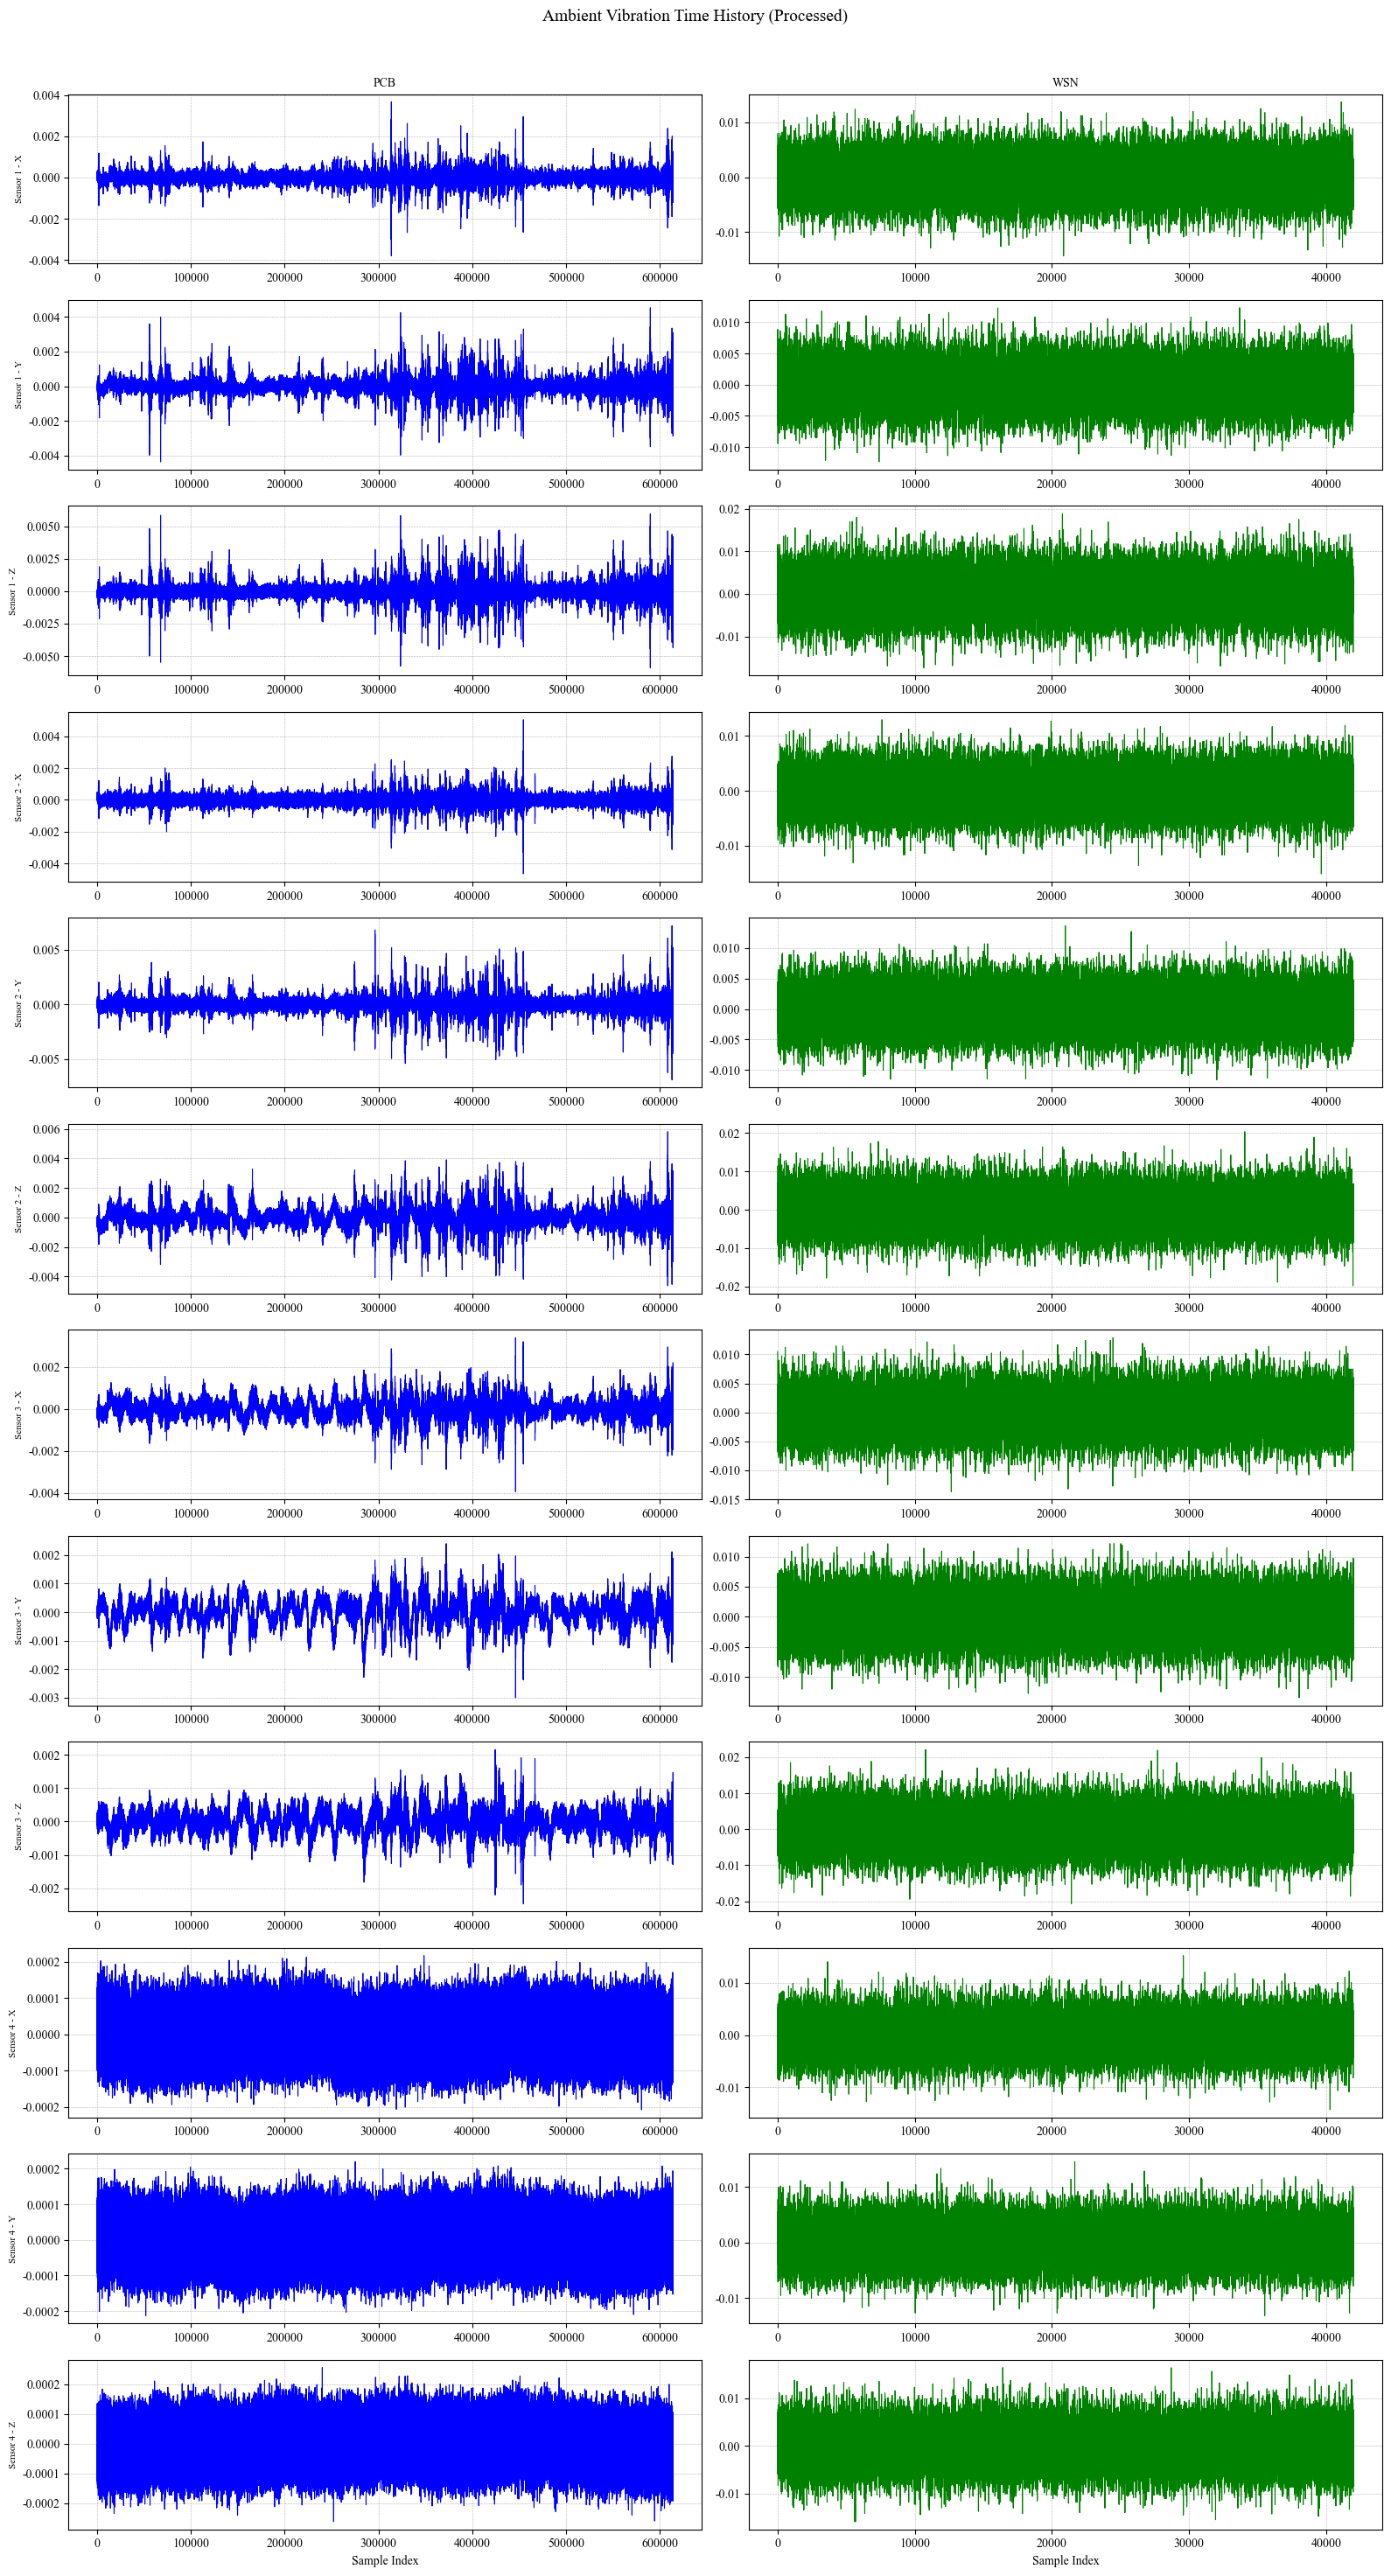

In [27]:
# === Time Vectors
time_pcb = np.arange(am_pcb_processed.shape[0])
time_wsn = np.arange(am_wsn_processed.shape[0])

# === Plot Figure 1 ===
fig, axes = plt.subplots(12, 2, figsize=(16, 30), sharex=False)

for i in range(12):
    # Left column: PCB
    axes[i, 0].plot(time_pcb, am_pcb_processed[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB", fontsize=10)

    # Right column: WSN
    axes[i, 1].plot(time_wsn, am_wsn_processed[:, i], color='green', linewidth=0.8)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Ambient Vibration Time History (Processed)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


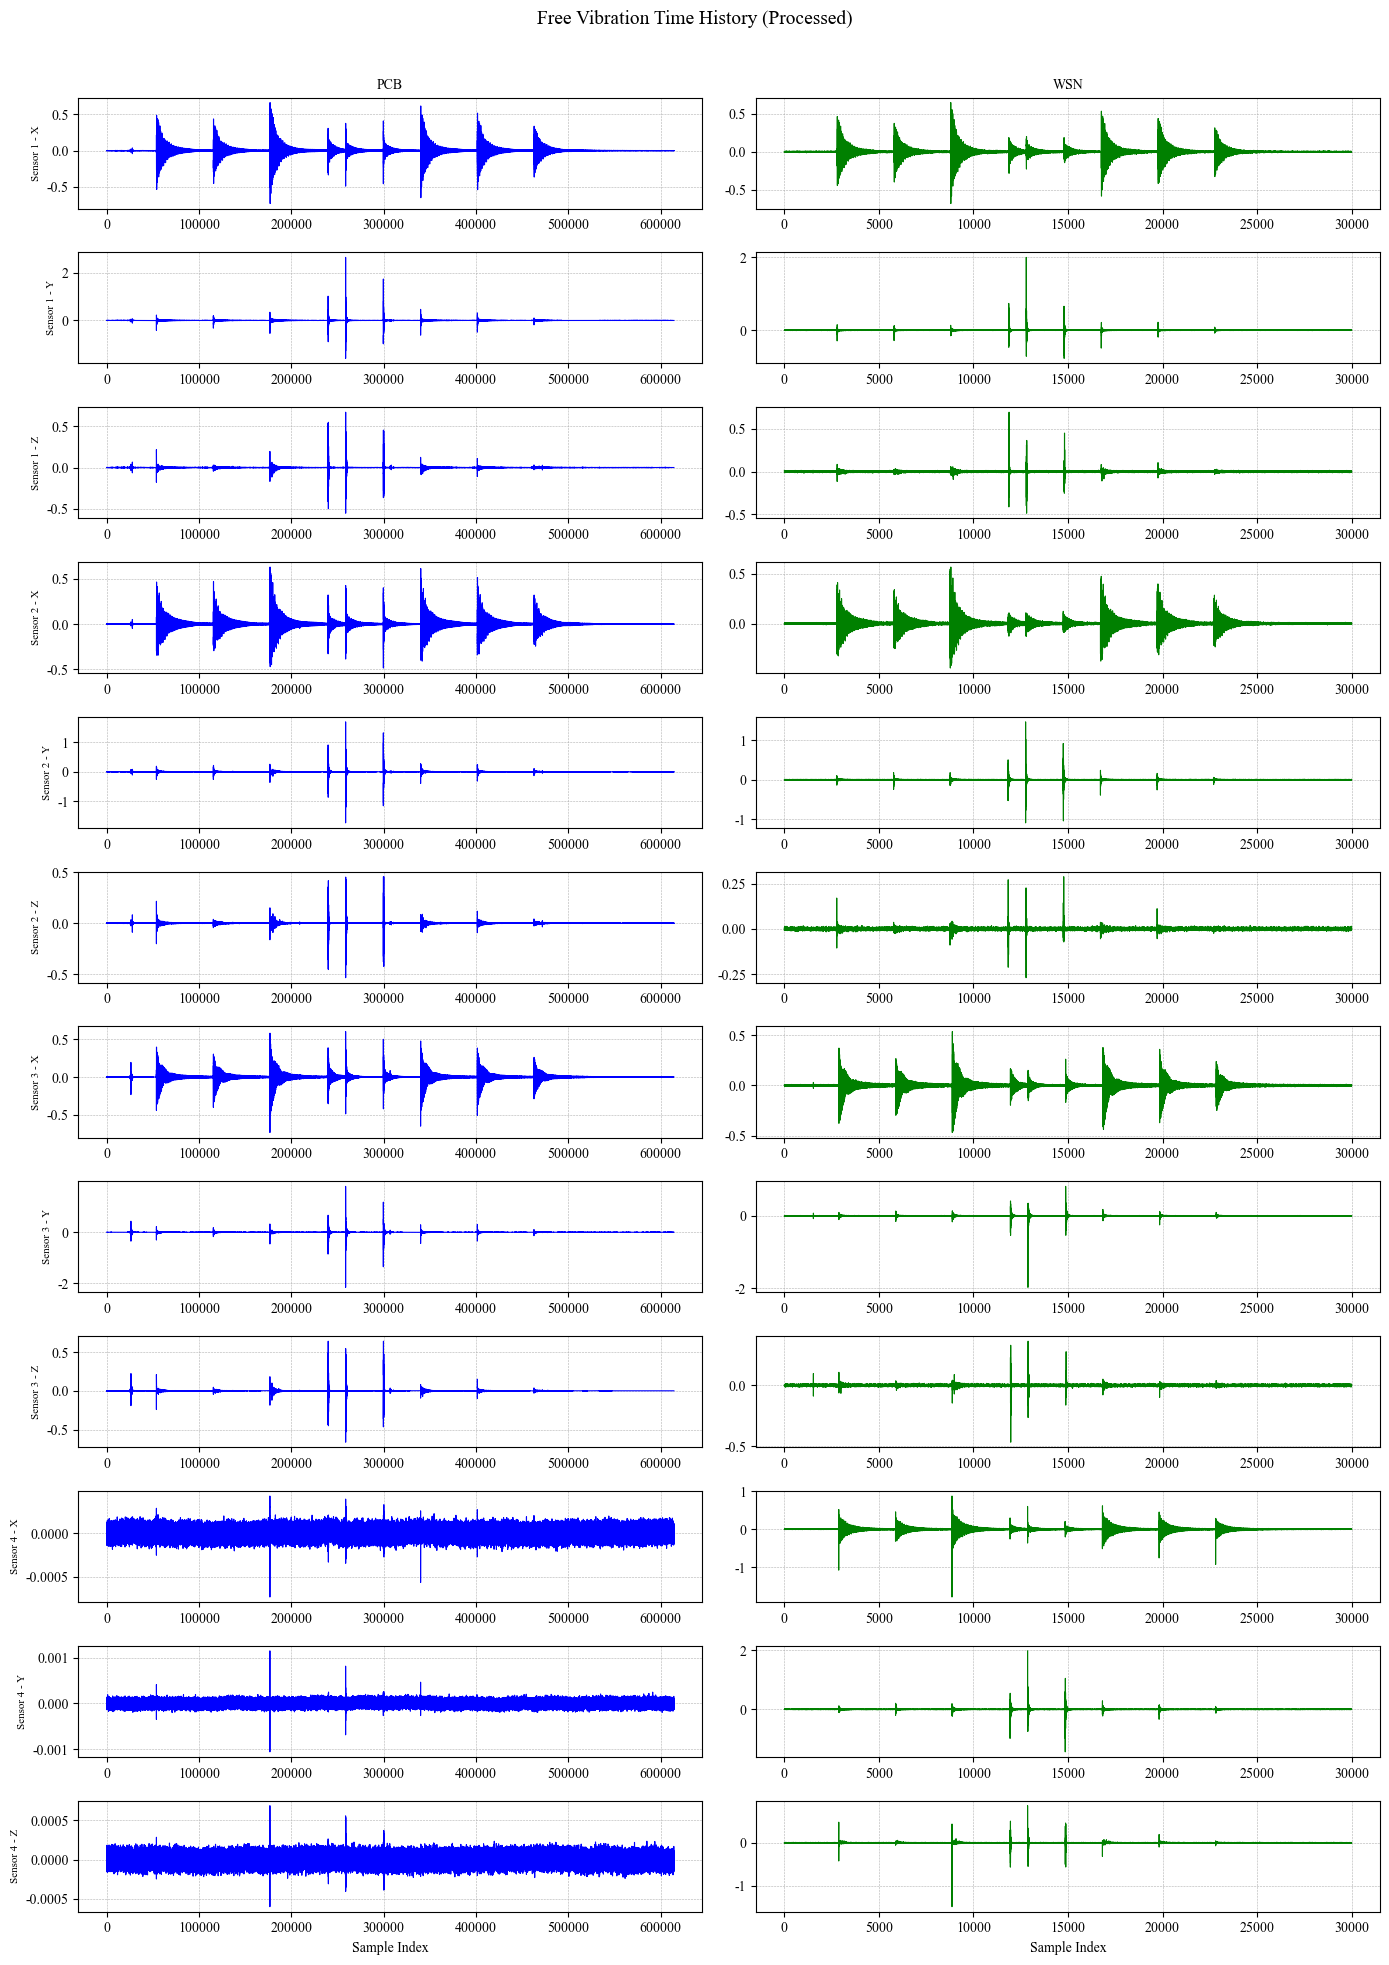

In [28]:
# === Time Vectors for free vibration ===
time_pcb_free = np.arange(free_pcb_processed.shape[0])
time_wsn_free = np.arange(free_wsn_processed.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot Free Vibration Time History ===
fig, axes = plt.subplots(12, 2, figsize=(14, 20), sharex=False)

for i in range(12):
    # Left column: PCB
    axes[i, 0].plot(time_pcb_free, free_pcb_processed[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB", fontsize=10)

    # Right column: WSN
    axes[i, 1].plot(time_wsn_free, free_wsn_processed[:, i], color='green', linewidth=0.8)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Free Vibration Time History (Processed)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


=== Ambient Vibration Delay Estimation ===
Ambient Channel  1 (Sensor 1 - X): -3.1138 s
Ambient Channel  2 (Sensor 1 - Y): -6.9341 s
Ambient Channel  3 (Sensor 1 - Z): -1.6118 s
Ambient Channel  4 (Sensor 2 - X): +0.7256 s
Ambient Channel  5 (Sensor 2 - Y): -5.2012 s
Ambient Channel  6 (Sensor 2 - Z): +4.3398 s
Ambient Channel  7 (Sensor 3 - X): -0.0898 s
Ambient Channel  8 (Sensor 3 - Y): -1.5986 s
Ambient Channel  9 (Sensor 3 - Z): +2.2773 s
Ambient Channel 10 (Sensor 4 - X): -1.9380 s
Ambient Channel 11 (Sensor 4 - Y): +3.5020 s
Ambient Channel 12 (Sensor 4 - Z): +0.5293 s


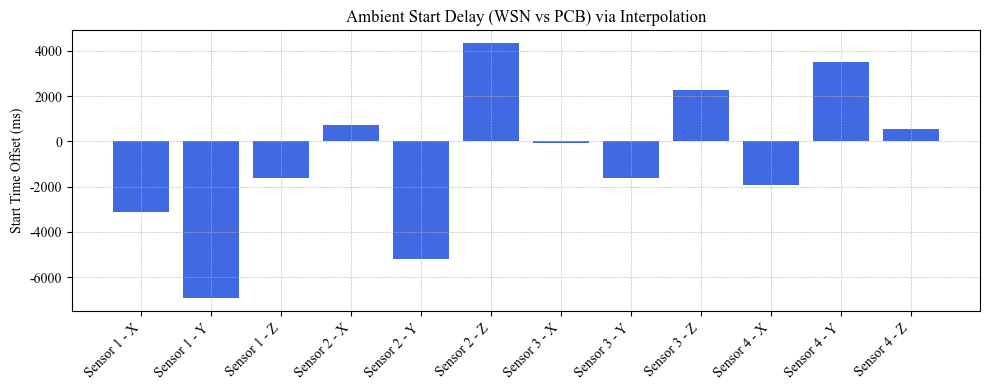


=== Free Vibration Delay Estimation ===
Free Channel  1 (Sensor 1 - X): -3.1816 s
Free Channel  2 (Sensor 1 - Y): +0.3022 s
Free Channel  3 (Sensor 1 - Z): +1.6455 s
Free Channel  4 (Sensor 2 - X): +3.4478 s
Free Channel  5 (Sensor 2 - Y): +1.2705 s
Free Channel  6 (Sensor 2 - Z): +2.5547 s
Free Channel  7 (Sensor 3 - X): -1.3608 s
Free Channel  8 (Sensor 3 - Y): -5.9355 s
Free Channel  9 (Sensor 3 - Z): -2.6099 s
Free Channel 10 (Sensor 4 - X): -1.7778 s
Free Channel 11 (Sensor 4 - Y): +3.7690 s
Free Channel 12 (Sensor 4 - Z): +1.3574 s


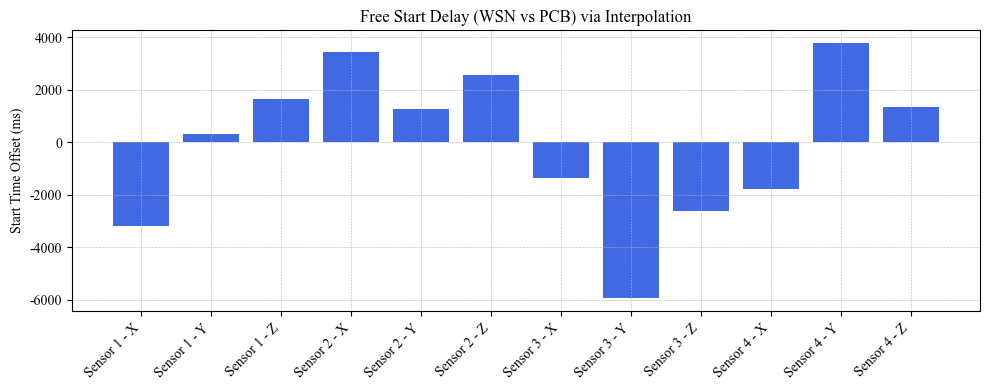

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.interpolate import interp1d

# === Constants ===
FS_PCB = 2048  # PCB sampling rate
FS_WSN = 100   # WSN sampling rate
WINDOW_SEC = 10  # Max duration for sync estimation
CHANNEL_LABELS = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Improved Sync Estimation Function ===
def estimate_delay_interp(pcb_ch, wsn_ch, fs_pcb, fs_wsn, window_sec=10):
    """
    Estimate delay between PCB and WSN using interpolation-based cross-correlation.
    """
    N_wsn = int(fs_wsn * window_sec)
    N_pcb = int(fs_pcb * window_sec)

    # Exclude first few points from WSN
    wsn_ch = wsn_ch[10:N_wsn]
    t_wsn = np.arange(len(wsn_ch)) / fs_wsn

    # Create interpolator and resample WSN at PCB time base
    interp_func = interp1d(t_wsn, wsn_ch, kind='cubic', fill_value="extrapolate")
    t_pcb = np.arange(N_pcb) / fs_pcb
    wsn_interp = interp_func(t_pcb[:len(t_wsn) * int(fs_pcb/fs_wsn)])

    # Ensure same length
    L = min(len(wsn_interp), len(pcb_ch))
    pcb_ch = pcb_ch[:L]
    wsn_interp = wsn_interp[:L]

    # Cross-correlation
    corr = correlate(pcb_ch, wsn_interp, mode='full')
    lag = np.argmax(corr) - (L - 1)
    delay_sec = lag / fs_pcb
    return delay_sec

# === Estimate Delay for Each Channel ===
def analyze_dataset(pcb_data, wsn_data, fs_pcb, fs_wsn, title_prefix=""):
    delays_sec = np.zeros(12)
    for ch in range(12):
        delay = estimate_delay_interp(
            pcb_data[:, ch], wsn_data[:, ch],
            fs_pcb=fs_pcb, fs_wsn=fs_wsn,
            window_sec=WINDOW_SEC
        )
        delays_sec[ch] = delay
        print(f"{title_prefix} Channel {ch+1:2d} ({CHANNEL_LABELS[ch]}): {delay:+.4f} s")

    # === Plot ===
    plt.figure(figsize=(10, 4))
    plt.bar(range(12), delays_sec * 1000, color='royalblue')
    plt.xticks(range(12), CHANNEL_LABELS, rotation=45, ha='right')
    plt.ylabel("Start Time Offset (ms)")
    plt.title(f"{title_prefix} Start Delay (WSN vs PCB) via Interpolation")
    plt.grid(True, linestyle='--', linewidth=0.4)
    plt.tight_layout()
    plt.show()

# === Run for Both Ambient and Free Vibration ===
print("=== Ambient Vibration Delay Estimation ===")
analyze_dataset(am_pcb_processed, am_wsn_processed, FS_PCB, FS_WSN, title_prefix="Ambient")

print("\n=== Free Vibration Delay Estimation ===")
analyze_dataset(free_pcb_processed, free_wsn_processed, FS_PCB, FS_WSN, title_prefix="Free")
